In [ ]:
import numpy as np 
import matplotlib.pyplot as plt
import pandas as pd
import scipy
import PIL
import requests

Make some sample data so that we have something to plot:

In [ ]:
np.random.seed(613)
x = np.arange(50) # creates x values
y = np.random.randint(0, 100,50) # creates y values

Make our basic scatterplot

In [ ]:
fig, ax = plt.subplots(figsize=(5, 3)) # creates Figure and Axes, the figure is 5 inches by 3 inches 
ax.scatter(x,y) # creates a scatterplot - each point is one observation

Modify the graph - keeping the figure and axis definition the same and only edit the axis object

In [ ]:
fig, ax = plt.subplots(figsize=(5, 3))
ax.bar(x,y)
# as you can see, different graph types require very little code change!

We can also make a line plot:

In [ ]:
fig, ax = plt.subplots(figsize=(5, 3))
ax.plot(x,y) # connect points with lines

Modify the existing code to produce a histogram:

In [ ]:
fig, ax = plt.subplots(figsize=(5, 3))
ax.hist(y) # to make a histogram, you only need the y variable
# histograms answer if the data is normal, skewed, if there are any outliers

Add axis labels and titles to th elast plot we made:

In [ ]:
fig, ax=plt.subplots(figsize=(5,3))
ax.plot(x,y)

ax.set_title('Total growth over time')
ax.set_ylabel('Total growth')
ax.set_xlabel('Years since start')
fig.tight_layout() # changes width and height of the figure to display cleaner automatically

We can modify our labels and titles appearance by using font dictionaries ('fontdict').
First make a dictionary with the properties we want for our labels. The dictionary stores key-value pairs.

In [ ]:
font1 = {'family':'sans-serif','color':'blue','size':20}
font2 = {'family':'monospace','color':'green','size':14}

Then we add fontdict arguments to our previous lineplot

In [ ]:
fig, ax = plt.subplots(figsize=(5, 3))
ax.plot(x,y)
ax.set_title('Total growth over time', fontdict = font1, loc = 'left') # loc = 'left' or 'center' or 'right' - changes label position
ax.set_ylabel('Total growth', fontdict = font2)
ax.set_xlabel('Years since start', fontdict = font2)
fig.tight_layout()

Remake the basic scatterplot but this time add color and marker arguments (AMERICAN SPELLING!)

In [ ]:
fig,ax=plt.subplots(figsize=(5,3))
ax.scatter(x,y, marker = '*', color = 'indigo')
# options: marker = '*', 'o', 's', '^'
# fig.show() # this code only needed if using .py... not for notebooks

Add lines to connect data points and then also adjust style and width of that line

In [ ]:
fig,ax=plt.subplots(figsize=(5,3))
ax.plot(x,y,marker = '*', color = 'indigo', linestyle = '--', linewidth = 2)

We can modify the colour using named colours or we can use hex codes!

In [ ]:
fig, ax = plt.subplots(figsize=(5, 3))
# color being the new addition
ax.plot(x,y,marker = '*', color = '#7425b9', linestyle = '--', linewidth = 2)

Customize further!

In [ ]:
fig, ax = plt.subplots(figsize=(5, 3))
ax.plot(x,y,marker = '*', markersize = 12, color = '#7425b9', linestyle = '--', linewidth = 2, markeredgecolor = '#fa9359', markerfacecolor = '#000000')

We can add grid lines to our axis object using .grid()

In [ ]:
fig, ax = plt.subplots(figsize=(5, 3))
ax.plot(x,y,marker = '*', markersize = 12, color = '#7425b9', linestyle = '--', linewidth = 2, markeredgecolor = '#fa9359', markerfacecolor = '#000000')
ax.grid(axis = 'y')

ACTIVITY: Can you modify the appearance (colour, width, linestyle) of our grid lines using what we learned before?

In [ ]:
fig, ax = plt.subplots(figsize=(5, 3))
ax.plot(x,y,marker = '*', markersize = 12, color = '#7425b9', linestyle = '--', linewidth = 2, markeredgecolor = '#fa9359', markerfacecolor = '#000000')
ax.grid(axis = 'y', color = 'darkorange', linestyle = '-.', linewidth = 1.5)

Activity: Visit the Python Graph Gallery at
https://python-graph-gallery.com/all-charts/.
Select one of the visualization types that you find most interesting.
COMPLETED FOR CLASS ON JUNE 03 2026

For your visualization of choice: https://python-graph-gallery.com/hexbin-map-from-geojson-python/
Hexbin map from geoJson file with Python

i. Copy the provided code and attempt to replicate the output in Python. NOTE: You may have to install packages.

ii. Recall the aesthetic,substantive, and perceptual qualities of data visualizations. Does your visualization of choice succeed in each area?

In [ ]:
import sys
print(sys.executable)

In [ ]:
# %pip install geopandas

i. Copy the provided code and attempt to replicate the output in Python. NOTE: You may have to install packages.

/var/folders/nt/63j9shsn0jd01bkbcff1gytw0000gn/T/ipykernel_4693/324619319.py:8: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  geoData["centroid"] = geoData.geometry.centroid


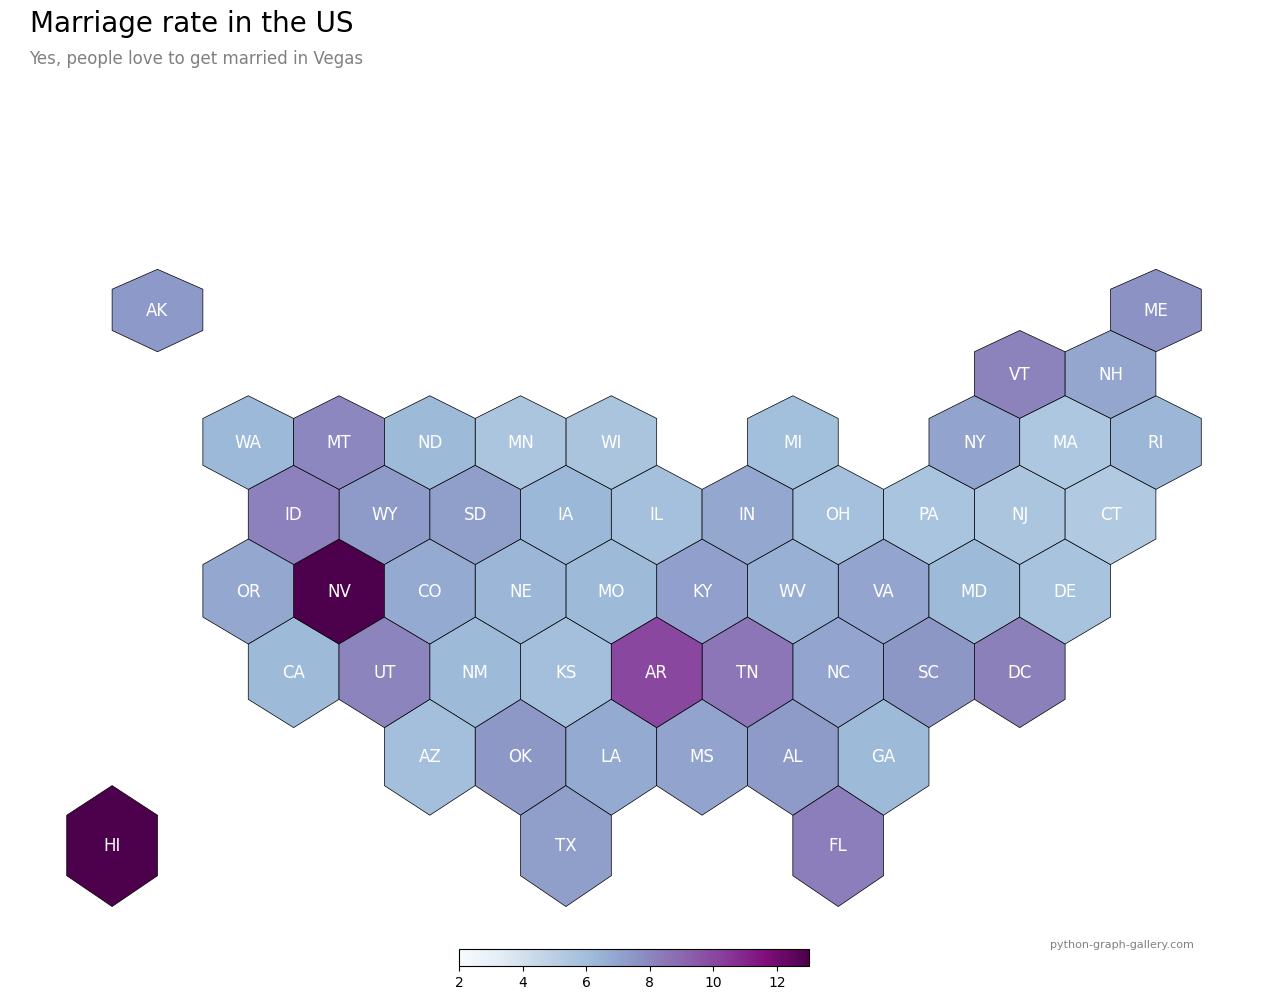

In [6]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt

url = "https://raw.githubusercontent.com/holtzy/The-Python-Graph-Gallery/master/static/data/us_states_hexgrid.geojson.json"
geoData = gpd.read_file(url)

geoData["centroid"] = geoData.geometry.centroid

mariageData = pd.read_csv(
    "https://raw.githubusercontent.com/holtzy/The-Python-Graph-Gallery/master/static/data/State_mariage_rate.csv"
)

geoData["state"] = geoData["google_name"].str.replace(
    r" \(United States\)",
    "",
    regex=True
)

geoData = geoData.set_index("state").join(
    mariageData.set_index("state")
)

fig, ax = plt.subplots(figsize=(13, 13))

geoData.plot(
    ax=ax,
    column="y_2015",
    cmap="BuPu",
    norm=plt.Normalize(vmin=2, vmax=13),
    edgecolor="black",
    linewidth=0.5
)

ax.axis("off")

for idx, row in geoData.iterrows():
    ax.annotate(
        text=row["iso3166_2"],
        xy=row["centroid"].coords[0],
        ha="center",
        va="center",
        color="white",
        fontsize=12
    )

fig.text(
    0.035,
    0.84,
    "Marriage rate in the US",
    fontsize=20,
    color="black",
    ha="left"
)

fig.text(
    0.035,
    0.815,
    "Yes, people love to get married in Vegas",
    fontsize=12,
    color="#808080",
    ha="left"
)

fig.text(
    0.82,
    0.135,
    "python-graph-gallery.com",
    fontsize=8,
    color="#808080"
)

sm = plt.cm.ScalarMappable(
    cmap="BuPu",
    norm=plt.Normalize(vmin=2, vmax=13)
)
sm.set_array([])

fig.colorbar(
    sm,
    ax=ax,
    orientation="horizontal",
    fraction=0.018,
    pad=0.01,
    shrink=0.28
)

fig.subplots_adjust(
    top=0.92,
    bottom=0.12,
    left=0.02,
    right=0.98
)

plt.show()

ii. Recall the aesthetic,substantive, and perceptual qualities of data visualizations. Does your visualization of choice succeed in each area?

I think the visualization succeeds aesthetically because it is uncluttered and nice to look at. The hexagonal layout gets rid of the irregular shapes of the states and the gradient scale blue-purple pallet is easy to look at. The labels and scale are clear.


The visualization also succeeds substantively because it effectively communicates the underlying data which is the marriage rates across the USA in 2015, allowing for the quick identification of states with higher and lower marriage rates. 

The visualization also succeeds perceptually because the differences in colour are easy to interpret (darker = higher marriage rate) THe legend povides a clear reference for interpreting the values and the equal sized hexagons reduces perceptual bias that would be found in the traditional maps where larger states may appear more important due to their size - with the caveat that this arrangement distorts the exact geographic locations/shapes of states making spatial relationships less intuitive. 